# Children's Media & Literacy: A Data Analysis
###Catalina Ontiveros CS-215 Final Project

## Does What Children Watch Shape How Well They Read?

### Project Overview
This analysis explores the intersection of children's television and literacy outcomes in the United States. We combine two datasets:
1. **NAEP (National Assessment of Educational Progress) Reading Data** – national Grade 4 and Grade 8 reading scores from 1992–2024.
2. **Children's TV Shows (IMDB-sourced)** – 106 children's shows from 1990–2024, including ratings, networks, educational classification, and episode counts.
### Research Questions
1. **(Trend):** How have national 4th- and 8th-grade reading scores changed over time?
2. **(Genre):** How Do Educational vs. Non-Educational Shows Compare?
3. **(Merged/Correlation):** Is there a relationship between the proportion of educational children's shows running in a given year and national literacy rates?

*Data Sources:*
- *NAEP Reading Data: nationsreportcard.gov*
- *Children's Shows: IMDB via custom dataset*

###Big Disclaimer
The custom dataset of children's shows was collected via a request to Claude.ai to collect viewer ratings from IMDb reports. [Here is the link to that chat](https://claude.ai/share/da27582d-1fa0-4457-8fb8-da71e806f26f)

In [ ]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

In [ ]:
# loading datasets

# Children's TV Shows
shows = pd.read_excel('/content/childrens_shows_via_imdb.xlsx')

# grade 4 reading levels
df_G4 = pd.read_csv("/content/NDECore_Reading_Levels_Grade_4.csv")

# Load Grade 8 reading levels
df_G8 = pd.read_csv("/content/NDECore_Reading_Levels_Grade_8.csv")

## Q1: How Have National Reading Scores Changed Over Time?

 Examining NAEP Grade 4 (percentage at or above Basic) and Grade 8 (average scale score) from 1992 to 2024.

,Year,at or above Basic
0,2024.0,60.0
1,2022.0,63.0
2,2019.0,66.0
3,2017.0,68.0
4,2015.0,69.0
5,2013.0,68.0
6,2011.0,67.0
7,2009.0,67.0
8,2007.0,67.0
9,2005.0,64.0


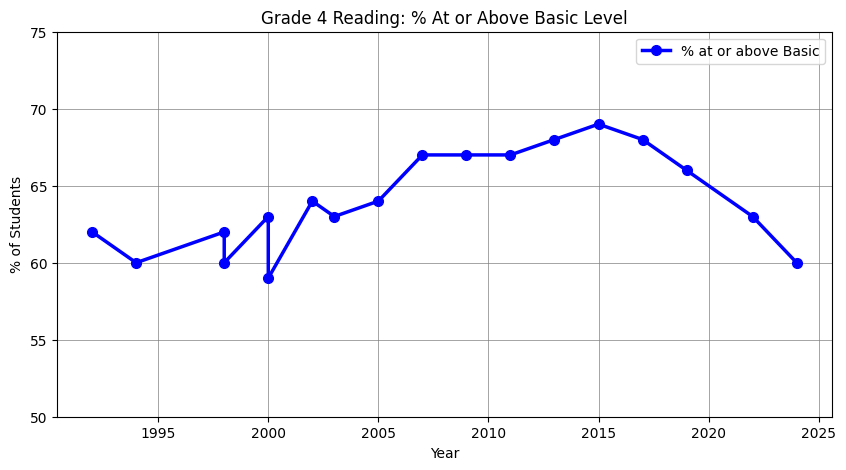

In [ ]:
# At or above basic reading levels
# Clean the 'Year' column in df_G4
df_G4['Year'] = df_G4['Year'].astype(str).str.replace('¹', '', regex=False)
df_G4['Year'] = pd.to_numeric(df_G4['Year'], errors='coerce')

# Drop rows where 'Year' or 'at or above Basic' is NaN after cleaning
df_G4_Basic = df_G4.dropna(subset=['Year', 'at or above Basic']).copy()

display(df_G4_Basic[['Year', 'at or above Basic']])

# Define the COLORS dictionary (example, adjust as needed)
COLORS = {'g4': 'blue', 'g8': 'green'}

# Plotting Grade 4 Reading: % At or Above Basic Level
plt.figure(figsize=(10, 5))
plt.plot(df_G4_Basic['Year'], df_G4_Basic['at or above Basic'],marker='o', linewidth=2.5,
         color=COLORS['g4'], markersize=7, label='% at or above Basic')

# Get the current axes object and assign it to G4
G4 = plt.gca()


G4.set_title("Grade 4 Reading: % At or Above Basic Level")
G4.set_xlabel("Year")
G4.set_ylabel("% of Students")
G4.set_ylim(50, 75)
G4.legend()

# Add major gridlines for horizontal and vertical axes
G4.xaxis.set_major_locator(MultipleLocator(5)) # Major ticks every 5 years
G4.yaxis.set_major_locator(MultipleLocator(5)) # Major ticks every 5 percentage points

G4.grid(which='major', linestyle='-', linewidth='0.5', color='gray')

plt.show()

,Year,Average scale score
0,2024.0,258.0
1,2022.0,260.0
2,2019.0,263.0
3,2017.0,267.0
4,2015.0,265.0
5,2013.0,268.0
6,2011.0,265.0
7,2009.0,264.0
8,2007.0,263.0
9,2005.0,262.0


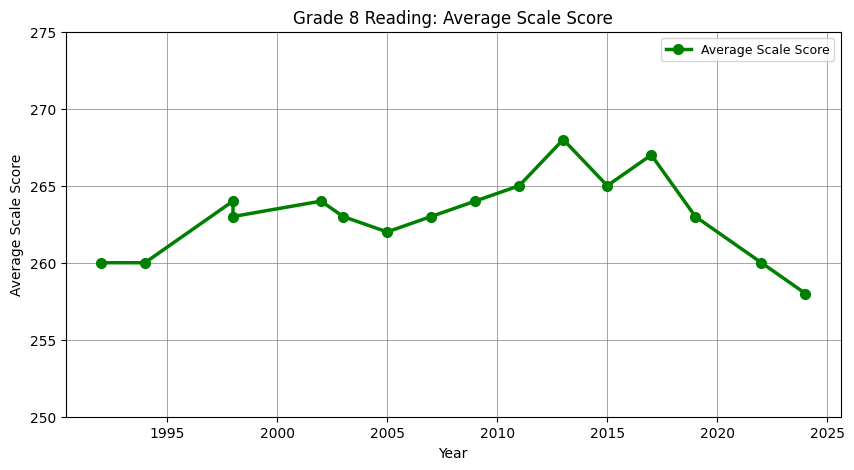

In [ ]:
# Clean the 'Year' column in df_G8
df_G8['Year'] = df_G8['Year'].astype(str).str.replace('¹', '', regex=False)
df_G8['Year'] = pd.to_numeric(df_G8['Year'], errors='coerce')

# Drop rows where 'Year' or 'Average scale score' is NaN after cleaning
df_G8_Avg = df_G8.dropna(subset=['Year', 'Average scale score']).copy()

display(df_G8_Avg[['Year', 'Average scale score']])

# Define the COLORS dictionary (example, adjust as needed)
# (Assuming COLORS might not be defined in this new cell's scope, or for clarity)
COLORS = {'g4': 'blue', 'g8': 'green'}

# Plotting Grade 8 Reading: Average Scale Score
plt.figure(figsize=(10, 5))
plt.plot(df_G8_Avg['Year'], df_G8_Avg['Average scale score'], marker='o', linewidth=2.5,
         color=COLORS['g8'], markersize=7, label='Average Scale Score')

# Get the current axes object and assign it to G8
G8 = plt.gca()

G8.set_title("Grade 8 Reading: Average Scale Score")
G8.set_xlabel("Year")
G8.set_ylabel("Average Scale Score")
G8.set_ylim(250, 275) # Adjust y-limits based on expected 8th-grade scores
G8.legend(fontsize=9)

# Add major gridlines for horizontal and vertical axes
G8.xaxis.set_major_locator(MultipleLocator(5)) # Major ticks every 5 years
G8.yaxis.set_major_locator(MultipleLocator(5)) # Major ticks every 5 percentage points

G8.grid(which='major', linestyle='-', linewidth='0.5', color='gray')

plt.show()

###**Key Findings:**
*   **Grade 4 Percentage at or above Basic:**

**Grade 4: % at or above Basic DECREASED by 6 percentage points from 2019 to 2024**

**Grade 4 best performance: 2015 (69% at or above basic)**

Grade 4 scores (percentage of students at or above basic reading level) also showed improvement from the early 1990s, peaking around 2015. However, following 2015, there has been a decline, bringing the 2024 percentage lower than its peak and slightly below the levels seen in the early 1990s.

*   **Grade 8 Average Scale Score:**

**Grade 8: Average score DROPPED by 5 points from 2019 to 2024**

**Grade 8 peak score: 2013 (268 points)**


Similarly, the scores for Grade 8 showed a general upward trend from the early 1990s to a peak around 2013. Since then, there has been a noticeable decline, with the 2024 score being lower than the 2013 peak and even slightly below some early 1990s scores. This indicates a recent decrease rather than a return to an earlier 'normal' higher average.


Both grades show a recent **decline** in reading performance after reaching peak levels, rather than a clear return to a specific 'normal' average. The current scores are generally lower than their recent peaks.

## Q2: How Do Educational vs. Non-Educational Shows Compare?

Comparing IMDB ratings across the two categories.

In [ ]:
#imdb data of all children's shows
shows

,imdb_id,title,genres,start_year,end_year,imdb_rating,num_votes,episode_count,title_type,network,is_educational,imdb_url,decade,still_running,pbs_kids
0,tt0103526,Mister Rogers' Neighborhood,"Comedy,Drama,Family,Educational",1990,2001.0,8.7,12000,895,tvSeries,PBS Kids,True,https://www.imdb.com/title/tt0103526,1990s,False,True
1,tt0103466b,Reading Rainbow,"Documentary,Family,Educational",1990,2006.0,8.5,6000,155,tvSeries,PBS Kids,True,https://www.imdb.com/title/tt0103466b,1990s,False,True
2,tt0098506,Sesame Street,"Animation,Comedy,Family,Educational",1990,NaN,8.2,24000,4500,tvSeries,PBS Kids,True,https://www.imdb.com/title/tt0098506,1990s,True,True
3,tt0098972,The Fresh Prince of Bel-Air,"Comedy,Family",1990,1996.0,7.9,125000,148,tvSeries,NBC,False,https://www.imdb.com/title/tt0098972,1990s,False,False
4,tt0101083,Tiny Toon Adventures,"Animation,Comedy,Family",1990,1995.0,7.6,9800,98,tvSeries,Fox/Syndicated,False,https://www.imdb.com/title/tt0101083,1990s,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,tt14168512,Star Trek: Prodigy,"Animation,Adventure,Family,Educational",2021,2024.0,7.4,12000,40,tvSeries,Paramount+,True,https://www.imdb.com/title/tt14168512,2020s,False,False
102,tt8398726,Donkey Hodie,"Animation,Comedy,Family,Educational",2021,NaN,7.2,400,40,tvSeries,PBS Kids,True,https://www.imdb.com/title/tt8398726,2020s,True,True
103,tt15314262,My Adventures with Superman,"Animation,Action,Adventure",2023,NaN,8.5,22000,24,tvSeries,Adult Swim/Max,False,https://www.imdb.com/title/tt15314262,2020s,True,False
104,tt10218470,Work It Out Wombats!,"Animation,Comedy,Family,Educational",2023,NaN,7.5,300,26,tvSeries,PBS Kids,True,https://www.imdb.com/title/tt10218470,2020s,True,True


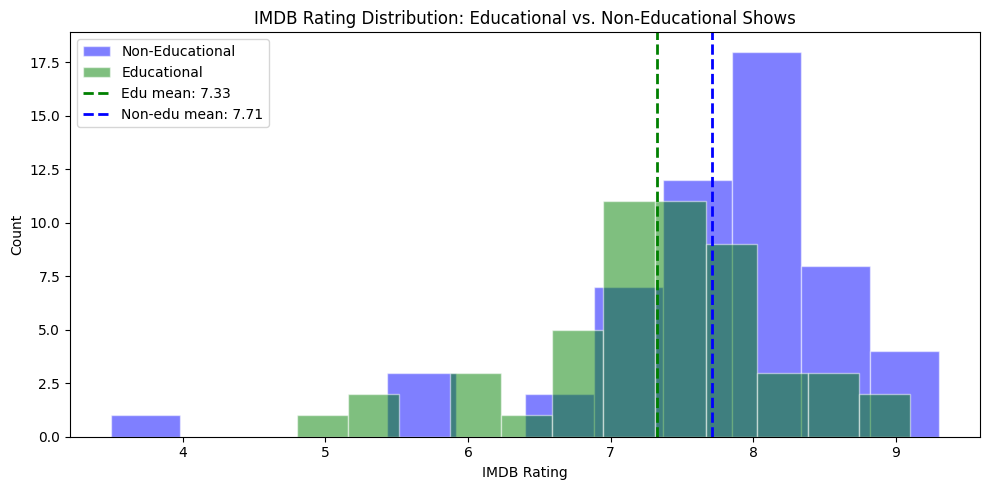

In [ ]:
# First, prepare the data for genre ratings by splitting and exploding the genres column
edu_mask = shows['is_educational']
edu_data = shows[edu_mask]
non_data = shows[~edu_mask]

# Define the COLORS dictionary with new entries for educational and non-educational
# (assuming COLORS might not be defined with these specific keys in this new cell's scope, or for clarity)
# If COLORS is already defined, this will add/update the specific keys.
# Using distinct colors for educational and non-educational categories.
if 'COLORS' not in globals(): # Initialize if not already defined globally
    COLORS = {}
COLORS.update({
    'edu': 'green', # A distinct color for educational shows
    'non_edu': 'blue' # A distinct color for non-educational shows
})

labels = ['Educational\n(n=51)', 'Non-Educational\n(n=55)']
palette = [COLORS['edu'], COLORS['non_edu']]

fig, ax = plt.subplots(figsize=(10, 5))

# Comparison of IMDB ratings for educational vs. non-educational shows using histplot
ax.hist(non_data['imdb_rating'].dropna(), bins=12, color=COLORS['non_edu'],
        alpha=0.50, label='Non-Educational', edgecolor='white')
ax.hist(edu_data['imdb_rating'].dropna(), bins=12, color=COLORS['edu'],
        alpha=0.50, label='Educational', edgecolor='white')
ax.axvline(edu_data['imdb_rating'].mean(), color=COLORS['edu'], linestyle='--', lw=2,
           label=f"Edu mean: {edu_data['imdb_rating'].mean():.2f}")
ax.axvline(non_data['imdb_rating'].mean(), color=COLORS['non_edu'], linestyle='--', lw=2,
           label=f"Non-edu mean: {non_data['imdb_rating'].mean():.2f}")

ax.set_title('IMDB Rating Distribution: Educational vs. Non-Educational Shows')
ax.set_xlabel('IMDB Rating')
ax.set_ylabel('Count')

ax.legend()
plt.tight_layout()
plt.show()

###**Key findings**
Educational shows (n=51) have a mean IMDB rating of approximately 7.3. Non-educational shows (n=55) have a mean IMDB rating of approximately 7.6.

The difference of ~0.3 points is small relative to both groups' spread. Both distributions are centered well above 7.0, meaning audiences and critics generally rate children's shows positively regardless of educational intent.

The slight gap in IMDB scores suggests entertainment and education are not mutually exclusive and that audiences largely accept educational programming when it's well-made.

**Notable caveat:** Our dataset of 106 shows was assembled via Claude.ai rather than a verified IMDB export, so sampling bias is possible. This analysis should be treated as exploratory rather than definitive.



##Q3: Is There a Correlation Between Educational Show Availability and Literacy?

**Methodology:** For each NAEP test year, calculate the percentage of children's shows available (that had started by that year) that were educational. We then correlate this against Grade 4 literacy metrics.

This is an **ecological correlation** — a population-level association, not individual causation. Many confounding factors (school policy, technology, socioeconomic backgrounds) are at play.

In [ ]:
#merging datasets for above basic reading levels for 4th graders, average reading scores for 8th graders, and educational shows vs total number of shows available

# Prepare show data to calculate educational show availability by year

# Determine the maximum year covered by the NAEP data for 'still_running' shows
max_naep_year = int(max(df_G4_Basic['Year'].max(), df_G8_Avg['Year'].max()))

# Create a temporary 'shows' DataFrame to handle 'end_year' for still running shows
shows_for_availability = shows.copy()
shows_for_availability['start_year'] = pd.to_numeric(shows_for_availability['start_year'], errors='coerce')
shows_for_availability['end_year'] = pd.to_numeric(shows_for_availability['end_year'], errors='coerce')

shows_for_availability['effective_end_year'] = shows_for_availability.apply(
    lambda row: row['end_year'] if pd.notna(row['end_year']) and not row['still_running']
    else (max_naep_year if row['still_running'] else row['end_year']), axis=1
)

# Drop rows where start_year or effective_end_year are NaN after conversion
shows_for_availability.dropna(subset=['start_year', 'effective_end_year'], inplace=True)

# Get all unique years from NAEP data to consider for show availability
# Use years from both G4 and G8 dataframes
all_naep_years = sorted(list(set(df_G4_Basic['Year'].dropna()).union(set(df_G8_Avg['Year'].dropna()))))

# 1. Create a DataFrame to store educational show availability metrics
show_availability_data = []

for year in all_naep_years:
    if not pd.isna(year): #skipping missing years
        current_year = int(year)

        # Filter shows available in the current year
        available_shows_in_year = shows_for_availability[
            (shows_for_availability['start_year'] <= current_year) &
            (shows_for_availability['effective_end_year'] >= current_year)
        ]

        total_shows_available = len(available_shows_in_year)
        # Summing boolean 'is_educational' directly counts True values
        educational_shows_available = available_shows_in_year['is_educational'].sum()

        pct_educational = (educational_shows_available / total_shows_available * 100) if total_shows_available > 0 else 0

        show_availability_data.append({
            'Year': float(current_year), # Keep year as float to match NAEP dataframes
            'Total Shows Available': total_shows_available,
            'Educational Shows Available': educational_shows_available,
        })

df_show_availability = pd.DataFrame(show_availability_data)

# 2. Merge with df_G4_Basic
# Select relevant columns from df_G4_Basic, including 'at or above Basic'
df_G4_relevant = df_G4_Basic[['Year', 'at or above Basic']]
merged_g4_shows = pd.merge(df_G4_relevant,
                           df_show_availability,
                           on='Year',
                           )

# 3. Merge with df_G8_Avg
# Select relevant columns from df_G8_Avg
df_G8_relevant = df_G8_Avg[['Year', 'Average scale score']]
final_correlation_df = pd.merge(merged_g4_shows,
                                df_G8_relevant,
                                on='Year',
                                )

# Rename columns for clarity in the final correlation DataFrame
final_correlation_df.rename(columns={
    'at or above Basic': '%_G4_at_or_above_Basic',
    'Average scale score': 'G8_Average_Scale_Score',
    'Total Shows Available': 'total_shows_available'
})

# Display the new dataset
display(final_correlation_df)


,Year,at or above Basic,Total Shows Available,Educational Shows Available,Average scale score
0,2024.0,60.0,31,19,258.0
1,2022.0,63.0,35,22,260.0
2,2019.0,66.0,36,22,263.0
3,2017.0,68.0,33,16,267.0
4,2015.0,69.0,35,18,265.0
5,2013.0,68.0,32,18,268.0
6,2011.0,67.0,31,18,265.0
7,2009.0,67.0,29,18,264.0
8,2007.0,67.0,34,16,263.0
9,2005.0,64.0,28,13,262.0


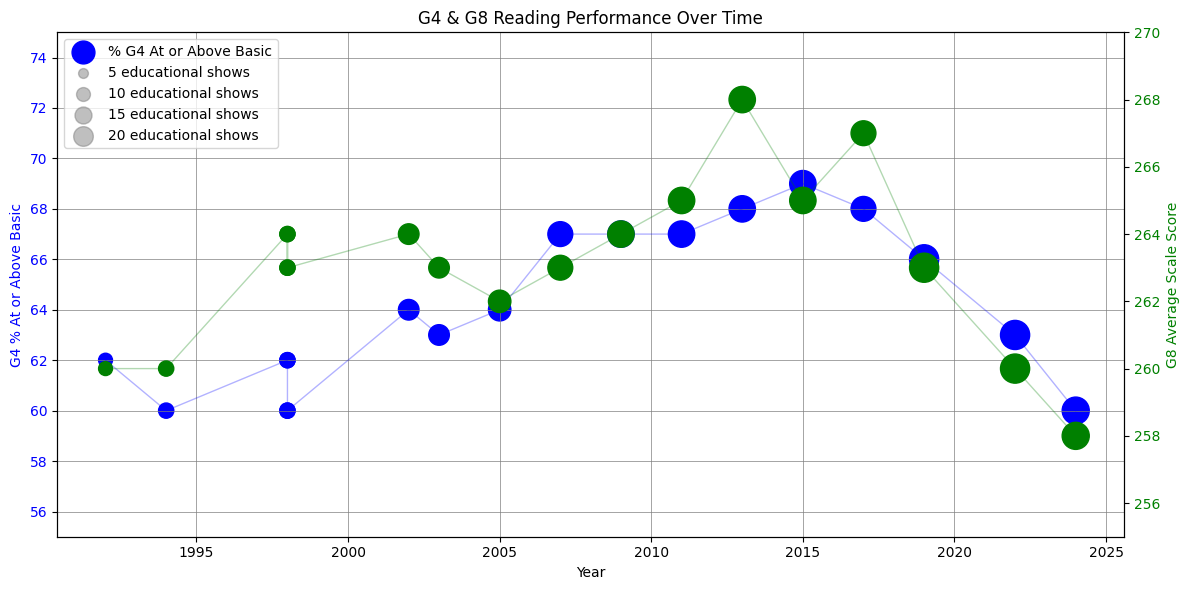

In [ ]:
#visualizing using a bubble chart
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

bubble_size = final_correlation_df['Educational Shows Available'] * 20

# G4 bubbles on left axis
scatter1 = ax1.scatter(
    x=final_correlation_df['Year'],
    y=final_correlation_df['at or above Basic'],
    s=bubble_size,
    color='Blue',
    label='% G4 At or Above Basic',
)

# G8 bubbles on right axis
scatter2 = ax2.scatter(
    x=final_correlation_df['Year'],
    y=final_correlation_df['Average scale score'],
    s=bubble_size,
    color='Green',
    label='G8 Avg Scale Score',
)

# Connect bubbles with faint lines so trends are easier to follow
ax1.plot(final_correlation_df['Year'], final_correlation_df['at or above Basic'],
         color='Blue', linewidth=1, alpha=0.3, zorder=2)
ax2.plot(final_correlation_df['Year'], final_correlation_df['Average scale score'],
         color='Green', linewidth=1, alpha=0.3, zorder=2)

# Bubble size legend
for n_shows in [5, 10, 15, 20]:
    ax1.scatter([], [], s=n_shows * 10, color='grey', alpha=0.5,
                label=f'{n_shows} educational shows')

# Axis labels and title
ax1.set_xlabel('Year')
ax1.set_ylabel('G4 % At or Above Basic', color='Blue')
ax2.set_ylabel('G8 Average Scale Score', color='Green')
ax1.tick_params(axis='y', labelcolor='Blue')
ax2.tick_params(axis='y', labelcolor='Green')

# Set y-axis limits for alignment
ax1.set_ylim(55, 75) # Adjust based on data range for G4
ax2.set_ylim(255, 270) # Adjust based on data range for G8

ax1.set_title('G4 & G8 Reading Performance Over Time')

# Combine all legend entries
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc='upper left')

# Add major gridlines for horizontal and vertical axes
ax1.xaxis.set_major_locator(MultipleLocator(5)) # Major ticks every 5 years
ax1.yaxis.set_major_locator(MultipleLocator(2)) # Major ticks every percentage point
ax2.yaxis.set_major_locator(MultipleLocator(2)) # Align with ax1's y-axis gridlines

ax1.grid(which='major', linestyle='-', linewidth='0.5', color='gray')

plt.tight_layout()
plt.show()

###**Correlation Analysis**
The bubble chart shows that as the number of educational children's shows available grew over time, reading scores did *not* rise in tandem — in fact, scores peaked and then fell while educational TV availability increased. This does not support a simple positive relationship between educational TV and national literacy.

This does *not* mean educational TV is harmful; it means population-level TV availability data is too blunt an instrument to detect whatever influence individual viewing might have on individual children's literacy. More granular, individual-level research would be needed to answer the original question rigorously.

###**Interpreting this (carefully):**

This is an **ecological correlation** at the population level, so we are comparing national averages, not individual children's viewing habits. Several important caveats apply:

1. **Confounding factors dominate.** School funding, teacher quality, economic inequality, screen time displacement of reading, and pandemic school closures all have far larger and more documented effects on literacy than TV programming choices.
2. **Impact of Social Media**
This study does not take into consideration the impact of social media platforms such as Instagram, YouTube, and TikTok on youth.
4. **Our dataset is small (106 shows).** With a custom-built dataset this size, classification errors or missing shows could meaningfully shift the educational show count in any given year.